# MA323 Assessed Groupwork Report
### Group 3: Lewis IRESON, Jade JIANG, Abishan ANANDARAJAN, Weiyu WANG, Tushar CHELLAMSETTY


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import time
# Global plotting defaults
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## Question 1: Approximation of Integrals and Infinite Sum - Numerical and Monte Carlo Approaches

### **1.1 Numerical Approximation of Integral 1**

We use the Trapezoidal Rule to approximate $I_1$. The formula is:
$$\int_0^2 f(x) dx \approx \frac{h}{2} \left[f(x_0) + 2\sum_{i=1}^{n-1} f(x_i) + f(x_n)\right]$$

To make sure the error $|E|$ is below $10^{-3}$, We use the error bound formula:
$$|E| \leq \frac{(b-a)^3}{12n^2} \max_{x \in [0, 2]} |f''(x)|$$

First, find the second derivative of $f(x) = (1+x^2)^{-1}$:
$$f'(x) = -2x(1+x^2)^{-2}$$
$$f''(x) = \frac{6x^2 - 2}{(1+x^2)^3}$$

In the interval $[0, 2]$, the maximum value of $|f''(x)|$ happens at $x=0$, which gives $|f''(0)| = |-2| = 2$.

Plug $a=0, b=2$ and the max value into the error bound:
$$|E| \leq \frac{2^3}{12n^2} \cdot 2 = \frac{16}{12n^2} = \frac{4}{3n^2}$$

To get the error $|E| \leq 10^{-3}$, we need:
$$\frac{4}{3n^2} \leq 10^{-3} \implies n^2 \geq \frac{4000}{3} \approx 1333.33 \implies n \geq 36.51$$

So, We choose **$n = 37$**. It ensures the approximation is accurate enough.

In [ ]:
# Define the integrand
def f(x):
    return 1 / (1 + x**2)

# Trapezoidal Rule implementation
def trapezoidal_approx(a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    # Standard formula: (h/2) * (f0 + 2*sum(f_mid) + fn)
    return (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])

# From our derivation, n=37 ensures error < 1e-3
n = 37
val_approx = trapezoidal_approx(0, 2, n)

# Exact value for comparison: arctan(2) - arctan(0)
val_exact = np.arctan(2)
actual_error = abs(val_approx - val_exact)
theo_bound = 4 / (3 * n**2)

print(f"Approximation: {val_approx:.6f}")
print(f"Exact Value:   {val_exact:.6f}")
print(f"Actual Error:  {actual_error:.2e}")
print(f"Error Bound:   {theo_bound:.2e}")

Approximation: 1.107110
Exact Value:   1.107149
Actual Error:  3.90e-05
Error Bound:   9.74e-04


### **1.2 Monte Carlo Estimation of Integral 2**

The integral $I_2$ has an $e^{-x}$ term, which is exactly the PDF of an Exponential distribution with $\lambda = 1$.

So, we can rewrite the integral as an expectation:
$$I_2 = \int_0^{\infty} \ln(1+x^2) e^{-x} dx = \mathbb{E}[\ln(1+X^2)], \quad X \sim \text{Exp}(1)$$

For the **Plain Monte Carlo**, sample $X_i$ independently from $\text{Exp}(1)$ and take the average:
$$\hat{I}_2 = \frac{1}{N} \sum_{i=1}^N \ln(1 + X_i^2)$$

To implement Antithetic Variates for variance reduction:

Since we can generate $X$ using the inverse transform $X = -\ln(U)$ where $U \sim \text{Uniform}(0, 1)$.

we can create a negatively correlated pair using $U$ and $1-U$.
- Let $X = -\ln(U)$
- Let $X' = -\ln(1-U)$

The paired estimator $Y_i$ is the average of these two:
$$Y_i = \frac{\ln(1+X_i^2) + \ln(1+(X_i')^2)}{2}$$
Then the AV estimator is just the mean of $M$ such pairs (total $2M$ samples):
$$\hat{I}_2^{anti} = \frac{1}{M} \sum_{i=1}^M Y_i$$

**Why it works (or doesn't):**
- For $f(x) = \ln(1+x^2)$, it is a **monotonically increasing** function. Use $U$ and $1-U$ creates a strong negative correlation between the samples, which helps cancel out the variance.
- For $f(x) = \cos(20x)$, the function is **highly oscillatory**. It's not monotonic, so $U$ and $1-U$ don't necessarily produce samples that "balance" each other out. The covariance might even be positive or near zero, making AV pretty much useless here.

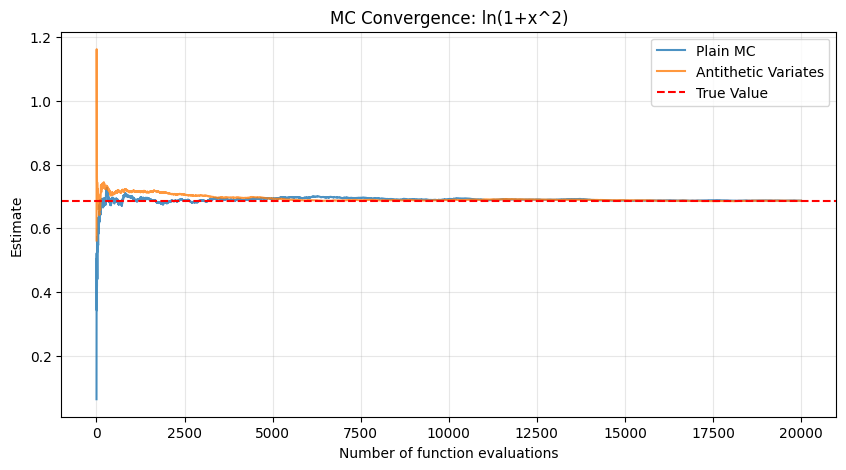

Results for ln(1+x^2):
  Plain MC Var: 0.590158
  Antithetic Var (scaled): 0.199368
  Variance Reduction Ratio: 2.96x
  Final Estimate (AV): 0.686771



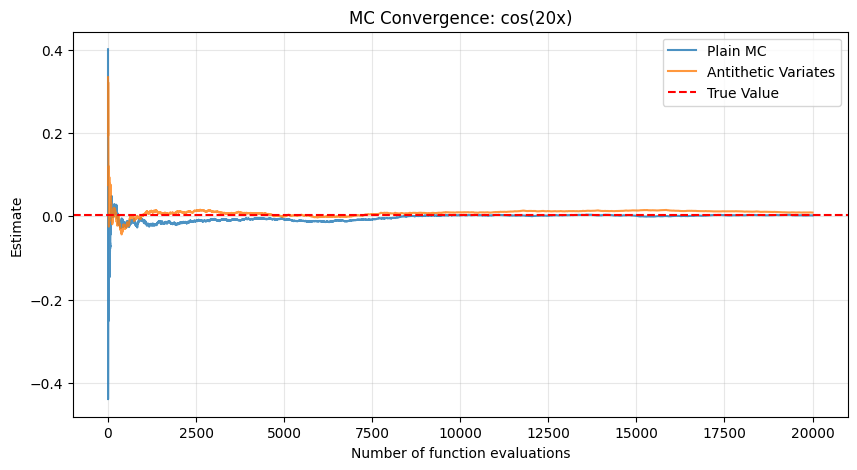

Results for cos(20x):
  Plain MC Var: 0.501754
  Antithetic Var (scaled): 0.396798
  Variance Reduction Ratio: 1.26x
  Final Estimate (AV): 0.008760



In [ ]:
from scipy.stats import expon

# Setup functions
g_ln = lambda x: np.log(1.0 + x**2)
g_cos = lambda x: np.cos(20.0 * x)

def run_mc_comparison(g, title, true_val, N_total=20000):
    rng = np.random.default_rng(42)

    # 1. Plain Monte Carlo
    U_plain = rng.random(N_total)
    X_plain = -np.log(U_plain)
    samples_plain = g(X_plain)
    estimates_plain = np.cumsum(samples_plain) / np.arange(1, N_total + 1)

    # 2. Antithetic Variates
    # use M = N_total // 2 pairs to keep function evaluations the same
    M = N_total // 2
    U_anti = rng.random(M)
    X1 = -np.log(U_anti)
    X2 = -np.log(1.0 - U_anti)

    # Each Y_i is the average of a pair
    samples_anti = 0.5 * (g(X1) + g(X2))
    estimates_anti = np.cumsum(samples_anti) / np.arange(1, M + 1)

    # Plotting
    plt.figure(figsize=(10, 5))
    # x-axis for plain is 1, 2, 3...
    plt.plot(np.arange(1, N_total + 1), estimates_plain, label='Plain MC', alpha=0.8)
    # x-axis for anti is 2, 4, 6... (each pair is 2 samples)
    plt.plot(np.arange(1, M + 1) * 2, estimates_anti, label='Antithetic Variates', alpha=0.8)

    plt.axhline(true_val, color='red', linestyle='--', label='True Value')
    plt.title(f'MC Convergence: {title}')
    plt.xlabel('Number of function evaluations')
    plt.ylabel('Estimate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Variance Analysis
    var_p = np.var(samples_plain)
    var_a = np.var(samples_anti) * 2
    reduction = var_p / var_a

    print(f"Results for {title}:")
    print(f"  Plain MC Var: {var_p:.6f}")
    print(f"  Antithetic Var (scaled): {var_a:.6f}")
    print(f"  Variance Reduction Ratio: {reduction:.2f}x")
    print(f"  Final Estimate (AV): {estimates_anti[-1]:.6f}\n")

# Get reference values using scipy
ref_ln = expon.expect(g_ln)
ref_cos = expon.expect(g_cos)

# Run experiments
run_mc_comparison(g_ln, "ln(1+x^2)", ref_ln)
run_mc_comparison(g_cos, "cos(20x)", ref_cos)

The antithetic variates method works by exploiting the negative correlation between paired samples. If $U \sim \mathcal{U}(0,1)$, then $X = F^{-1}(U)$ and $X' = F^{-1}(1-U)$ have the same distribution but are negatively correlated. This correlation helps cancel out errors and reduces the variance.

For $\ln(1+x^2)$, the function is monotonically increasing. Since $X = -\ln U$ and $X' = -\ln(1-U)$ are negatively correlated, $g(X)$ and $g(X')$ also maintain a strong negative correlation. This leads to a clear variance reduction of about **2.96x** (plain MC variance: 0.590158, scaled antithetic variance: 0.199368).

For $\cos(20x)$, the function is not monotone due to rapid oscillations. $g(X)$ and $g(X')$ no longer have a stable negative correlation, so the variance reduction is much smaller, only about **1.26x** (plain MC variance: 0.501754, scaled antithetic variance: 0.396798). This is also reflected in the plots, where both lines show similar levels of fluctuation.

### **1.3 Monte Carlo Estimation of the Sum S**

The sum $S$ is:
$$S = \sum_{k=0}^\infty \frac{e^{-2} 2^k}{k! (1+k^2)}$$

We can see that the term $\frac{e^{-2} 2^k}{k!}$ is exactly the probability $\mathbb{P}(K=k)$.  $K$ follows a **Poisson distribution** with $\lambda = 2$.

So, this infinite series is actually the expected value:
$$S = \mathbb{E}\left[\frac{1}{1+K^2}\right], \quad K \sim \text{Poisson}(2)$$

To estimate this using Monte Carlo, generate $N$ independent samples $K_1, \dots, K_N$ from the Poisson(2) distribution.

Then the estimator is just the sample mean:
$$\hat{S} = \frac{1}{N} \sum_{i=1}^N \frac{1}{1+K_i^2}$$


MC estimate of S = 0.35068177


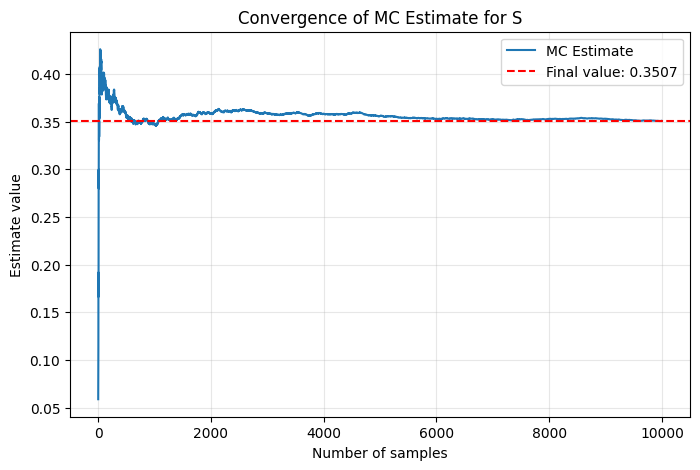

In [ ]:
# Monte Carlo
rng = np.random.default_rng(42)
n_samples = 10000

# Sample from Poisson(2)
K = rng.poisson(lam=2.0, size=n_samples)
samples = 1.0 / (1.0 + K**2)

# Calculate running mean to see convergence
running_mean = np.cumsum(samples) / np.arange(1, n_samples + 1)
s_final = running_mean[-1]

print(f"MC estimate of S = {s_final:.8f}")

# Plot the convergence
plt.figure(figsize=(8, 5))
plt.plot(running_mean, label='MC Estimate')
plt.axhline(s_final, color='red', linestyle='--', label=f'Final value: {s_final:.4f}')
plt.xlabel('Number of samples')
plt.ylabel('Estimate value')
plt.title('Convergence of MC Estimate for S')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Question 2: Monte Carlo estimation of e

### **2.1 Representation of e as an Expected Stopping Time**

**2.1.1**

Assume that $N \ge 0$ and that $N \in \mathbb{N} = \{0,1,2,\dots\}$. Then, by the definition of expectation for a non-negative integer-valued random variable,
$$
\mathbb{E}[N] = \sum_{m=0}^{\infty} m\,\mathbb{P}(N = m).
$$
For each integer $m \ge 0$, we can write
$$
m = \sum_{n=0}^{m-1} 1.
$$
Hence
$$
\mathbb{E}[N]
= \sum_{m=0}^{\infty} \left( \sum_{n=0}^{m-1} 1 \right) \mathbb{P}(N = m)
= \sum_{m=0}^{\infty} \sum_{n=0}^{m-1} \mathbb{P}(N = m).
$$
The double sum above runs over all pairs $(n,m)$ such that $ 0 ≤ n ≤ m-1 $  which is equivalent to $n \ge 0$ and $m \ge n+1$. Hence, we can swith the order of the summation by first fixing $n \ge 0$ and then sum over $m \ge n+1$. Therefore
$$
\mathbb{E}[N] = \sum_{n=0}^{\infty} \sum_{m = n+1}^{\infty} \mathbb{P}(N = m).
$$
For fixed $n$, we have
$$
\sum_{m = n+1}^{\infty} \mathbb{P}(N = m) = \mathbb{P}(N \ge n+1),
$$
and so we obtain the identity
$$
\mathbb{E}[N] = \sum_{n=0}^{\infty} \mathbb{P}(N \ge n+1).
$$

**2.1.2**


**Base case ($n=1$):** The 1-dimensional simplex is
$$
\{x_1 \in [0,1] : x_1 \le 1\} = [0,1],
$$
so its volume is
$$
V_1 = \int_0^1 1 \, dx_1 = 1 = \frac{1}{1!}.
$$

Hence the base case is satisfied.

**Induction step:** Assume that for some $k \in \mathbb{N}$ we have $V_k = \frac{1}{k!}$. We show that
$$
V_{k+1} = \frac{1}{(k+1)!}.
$$

Consider the $(k+1)$-dimensional simplex

$$
\{(x_1,\dots,x_{k+1}) \in [0,1]^{k+1} : x_1 + \dots + x_k + x_{k+1} \le 1\}.
$$

Fix $x_{k+1} = t \in [0,1]$. Then the condition becomes
$$x_1 + \dots + x_n \le 1 - t, $$


Thus, for each fixed $t$, the set of $(x_1,\dots,x_k)$ is an $k$-dimensional simplex scaled by the factor $(1 - t)$ in each coordinate. Its volume is therefore $$ (1 - t)^k \, V_k.$$

We find the total volume of $V_{k+1}$ by integrating this scaled cross sectional volume over $t$


Using the induction hypothesis $V_k = \frac{1}{k!}$, we obtain


$$
V_{k+1} = \int_0^1 (1 - t)^k \, V_k \, dt
= \frac{1}{k!} \int_0^1 (1 - t)^k \, dt.
$$

Evaluating the integral gives
$$
\int_0^1 (1 - t)^k \, dt = \frac{1}{k+1},
$$
so
$$
V_{k+1} = \frac{1}{k!} \cdot \frac{1}{k+1} = \frac{1}{(k+1)!}.
$$

By the principle of  induction, we conclude that
$$
V_n = \frac{1}{n!} \quad \text{for all } n \in \mathbb{N}.
$$



**2.1.3**
Recall that $N$ is defined by
$$
N = \min\{n \ge 1 : U_1 + \dots + U_n > 1\},
$$
where $(U_i)_{i \ge 1}$ are i.i.d. $\mathrm{U}(0,1)$ random variables. For each $n \ge 0$,
$$
\{N \ge n+1\} = \{U_1 + \dots + U_n \le 1\}.
$$
Hence
$$
\mathbb{P}(N \ge n+1) = \mathbb{P}(U_1 + \dots + U_n \le 1).
$$

We are given in the question
$$
\mathbb{P}(U_1 + \dots + U_n \le 1) = V_n.
$$
We now apply the identity from **Part I** to our specific random variable $N$ and from **Part II**  we know that $V_n = \frac{1}{n!}$ for all $n$. Combining these two facts we get,

$$
\mathbb{E}[N]
= \sum_{n=0}^{\infty} \mathbb{P}(U_1 + \dots + U_n \le 1)
= \sum_{n=0}^{\infty} V_n
= \sum_{n=0}^{\infty} \frac{1}{n!}
= e.
$$


### **2.2 Monte Carlo estimator for e**

We now explain the theoretical idea behind our Monte Carlo approach before presenting the code.

Suppose we would like to estimate an expectation of the form
$$
\mathbb{E}(N) = \mathbb{E}(h(U)) = e
$$

In our setting we simulate $M$ independent copies of $N$. In each simulation $k = 1,\dots,M$ we generate uniforms $U_1, U_2, \dots$ sequentially until the partial sum $U_1 + \dots + U_{N^{(k)}}$ first exceeds $1$, and record the corresponding number of draws $N^{(k)}$. The resulting values $N^{(1)},\dots,N^{(M)}$ are i.i.d. samples with the same distribution as $N$, so their sample mean
$$
\hat{e}_M = \frac{1}{M} \sum_{k=1}^M N^{(k)}
$$
is a Monte Carlo estimator for $\mathbb{E}(N)$. Since $N$ has finite mean and variance, the Strong Law of Large Numbers and the Central Limit Theorem apply: the estimator $\hat{e}_M$ converges almost surely to $e$ as $M \to \infty$ and is approximately normal for large $M$. In the code section below we use this to find our  Monte Carlo estimator, form an approximate 95\% confidence interval for $e$ and to plot the running estimate against the number of samples to visualise the convergence of the Monte Carlo estimator.

True value of e: 2.7183
Monte Carlo estimate: 2.7260
95% confidence interval: (2.70870, 2.74330)


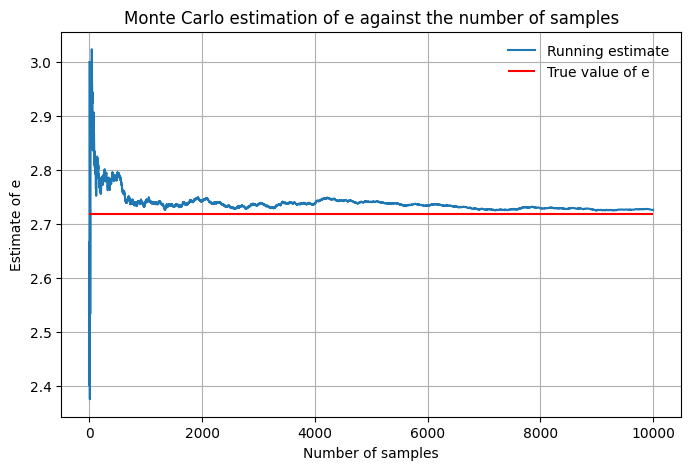

In [ ]:
M = 10_000 # Number of MC Simulations
rng = np.random.default_rng(seed=12345)
N_samples = np.zeros(M) #**

#Simulate  N
for k in range(M):
    sum_U = 0.0
    n_draws = 0
    while sum_U <= 1.0:
        sum_U += rng.random()  # generate U ~ U(0,1)
        n_draws  += 1
    N_samples[k] = n_draws

e_estimate = N_samples.mean()
sample_std = N_samples.std()
std_err = sample_std / np.sqrt(M)

alpha = 0.05
z_critical = stats.norm.ppf(1 - alpha / 2)
ci_lower = e_estimate - z_critical * std_err
ci_upper = e_estimate + z_critical * std_err

print(f"True value of e: {np.exp(1):.4f}")
print(f"Monte Carlo estimate: {e_estimate:.4f}")
print(f"95% confidence interval: ({ci_lower:.5f}, {ci_upper:.5f})")

# Plot of running estimate
running_estimate = np.cumsum(N_samples) / np.arange(1, M + 1)

fig, ax = plt.subplots()

ax.plot(
    np.arange(1, M + 1),
    running_estimate,
    label='Running estimate'
)

ax.hlines(
    np.exp(1),
    xmin=1,
    xmax=M,
    colors='red',
    label='True value of e'
)

ax.set_title('Monte Carlo estimation of e against the number of samples')
ax.set_xlabel('Number of samples')
ax.set_ylabel('Estimate of e')
ax.legend(frameon=False)

plt.show()

The Monte Carlo simulation yields an estimate that lies close to the true value of $e$, and the corresponding $95\%$ confidence interval is reasonably tight and includes $e$, indicating that the sampling variability at $M = 10{,}000$ replications is small and that the normal-approximation interval performs as expected. From the plot we can see the Monte Carlo simulation produces an estimator that fluctuates considerably for small sample sizes but then stabilises in a narrow band close to the true value of $e$ once several thousand samples have been drawn. This is consistent with the Strong Law of Large Numbers and the Central Limit Theorem discussed earlier: as $M$ increases, the running mean $\hat e_M$ converges almost surely to $e$ and the Monte Carlo error decays at rate $O(M^{-1/2})$.

## Question 3: European Basket Call Option


### **3.1: Monte Carlo Estimator**

**3.1.1 Risk-Neutral Pricing**

By the Fundamental Theorem of Asset Pricing, in a complete
arbitrage-free market the time-0 price of any derivative is:

$$V_0 = e^{-rT} \mathbb{E}^Q[H]$$

where $H = \left(\frac{1}{2}(S_T^A + S_T^B) - K\right)^+$
is the payoff at maturity $T$.

**3.1.2 Monte Carlo Estimator**

Since $\mathbb{E}^Q[H]$ has no closed form, we approximate it by:

$$\hat{V}_0 = e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} H_i$$

where each simulated payoff is:

$$H_i = \left(\frac{1}{2}(S_T^{A,(i)} + S_T^{B,(i)}) - K\right)^+$$

and the terminal stock prices are:

$$S_T^{A,(i)} = S_0^A \exp\left(\left(r - \frac{\sigma^2}{2}\right)T
+ \sigma\sqrt{T} Z_1^{(i)}\right)$$

$$S_T^{B,(i)} = S_0^B \exp\left(\left(r - \frac{\eta^2}{2}\right)T
+ \eta\sqrt{T}\left(\rho Z_1^{(i)}
+ \sqrt{1-\rho^2} Z_2^{(i)}\right)\right)$$

with $Z_1^{(i)}, Z_2^{(i)} \stackrel{\text{iid}}{\sim} N(0,1)$.

**3.1.3 Justification**

1. By the **Fundamental Theorem of Asset Pricing**,
the no-arbitrage price equals the discounted
risk-neutral expectation. Under $Q$, both stocks
grow at the risk-free rate $r$.

2. Since each simulation uses fresh independent draws,
$H_1, H_2, \ldots, H_N$ are i.i.d. By the
**Law of Large Numbers**:

$$\frac{1}{N}\sum_{i=1}^{N} H_i \to \mathbb{E}^Q[H]
\quad \text{as } N \to \infty$$

3. The estimator is **unbiased** since:

$$\mathbb{E}[\hat{V}_0] = e^{-rT} \cdot \frac{1}{N}
\sum_{i=1}^{N} \mathbb{E}[H_i] = e^{-rT}\mathbb{E}^Q[H] = V_0$$

### **3.2: Generating Correlated Random Variables**

We need to simulate $W_T^A$ and $W_T^B$ jointly, where:

$$\begin{pmatrix} W_T^A \\ W_T^B \end{pmatrix} \sim N_2(0, \Sigma),
\quad \Sigma = \begin{pmatrix} T & T\rho \\ T\rho & T \end{pmatrix}$$

**3.2.1 Generate independent standard normals**

We first generate two independent $Z_1, Z_2 \sim N(0,1)$.
From first principles these can be obtained via the
Box-Muller transform: given $U_1, U_2 \sim U(0,1)$:

$$Z_1 = \sqrt{-2\ln U_1}\cos(2\pi U_2), \quad
Z_2 = \sqrt{-2\ln U_1}\sin(2\pi U_2)$$

In practice we use `numpy.random.randn()`.

**3.2.2 Cholesky decomposition**

We factorise $\Sigma = AA^T$ where $A$ is lower triangular.
Writing $A = \begin{pmatrix} a & 0 \\ b & c \end{pmatrix}$
and matching entries:

- $a^2 = T \implies a = \sqrt{T}$
- $ab = T\rho \implies b = \sqrt{T}\rho$
- $b^2 + c^2 = T \implies c = \sqrt{T(1-\rho^2)}$

So:

$$A = \begin{pmatrix} \sqrt{T} & 0 \\
\sqrt{T}\rho & \sqrt{T(1-\rho^2)} \end{pmatrix}$$

**3.2.3 Apply the transformation**

$$\begin{pmatrix} W_T^A \\ W_T^B \end{pmatrix} = A
\begin{pmatrix} Z_1 \\ Z_2 \end{pmatrix} =
\begin{pmatrix} \sqrt{T}Z_1 \\
\sqrt{T}\rho Z_1 + \sqrt{T(1-\rho^2)}Z_2 \end{pmatrix}$$

**3.2.4 Verification**

- $\text{Var}(W_T^A) = T \cdot \text{Var}(Z_1) = T$ ✓
- $\text{Var}(W_T^B) = T\rho^2 + T(1-\rho^2) = T$ ✓
- $\text{Cov}(W_T^A, W_T^B) = \sqrt{T} \cdot \sqrt{T}\rho
\cdot \text{Var}(Z_1) = T\rho$,
so $\text{Corr}(W_T^A, W_T^B) = \rho$ ✓

### **3.3: Python code that computes the approximation of the time-0 price of the option using a Monte-Carlo estimator**

In [ ]:
# PARAMETERS

S0_A = 100    # Initial price of stock A
S0_B = 100    # Initial price of stock B
K    = 100    # Strike price
r    = 0.02   # Risk-free rate
sigma = 0.2   # Volatility of stock A
eta   = 0.3   # Volatility of stock B
rho   = 0.5   # Correlation between the two Brownian motions
T     = 1.0   # Maturity
N     = 100000  # Number of Monte Carlo simulations


# STEP 1: Generate independent standard normals
# Z1 and Z2 are independent N(0,1)
# Shape (N,) means N samples each

np.random.seed(42)
Z1 = np.random.randn(N)
Z2 = np.random.randn(N)


# STEP 2: Apply Cholesky transformation
# W_A = sqrt(T) * Z1
# W_B = sqrt(T) * (rho*Z1 + sqrt(1-rho^2)*Z2)
# This gives Corr(W_A, W_B) = rho as required

W_A = np.sqrt(T) * Z1
W_B = np.sqrt(T) * (rho * Z1 + np.sqrt(1 - rho**2) * Z2)


# STEP 3: Simulate terminal stock prices using GBM formula
# S_T = S0 * exp((r - vol^2/2)*T + vol*W_T)

ST_A = S0_A * np.exp((r - 0.5 * sigma**2) * T + sigma * W_A)
ST_B = S0_B * np.exp((r - 0.5 * eta**2)   * T + eta   * W_B)


# STEP 4: Compute payoffs
# H_i = max(0.5*(ST_A + ST_B) - K, 0)
# np.maximum handles the positive part

payoffs = np.maximum(0.5 * (ST_A + ST_B) - K, 0)


# STEP 5: Discount and average to get price
# V0 = e^(-rT) * (1/N) * sum(H_i)

price = np.exp(-r * T) * np.mean(payoffs)

# 95% confidence interval using CLT
# Standard error = std(payoffs) / sqrt(N)
std_payoffs = np.std(payoffs)
standard_error = std_payoffs / np.sqrt(N)
ci_lower = np.exp(-r * T) * (np.mean(payoffs) - 1.96 * standard_error)
ci_upper = np.exp(-r * T) * (np.mean(payoffs) + 1.96 * standard_error)

print(f"Monte Carlo price:       {price:.4f}")
print(f"95% Confidence Interval: ({ci_lower:.4f}, {ci_upper:.4f})")

Monte Carlo price:       9.6529
95% Confidence Interval: (9.5579, 9.7479)


### **3.4: Using the code for a specific case**

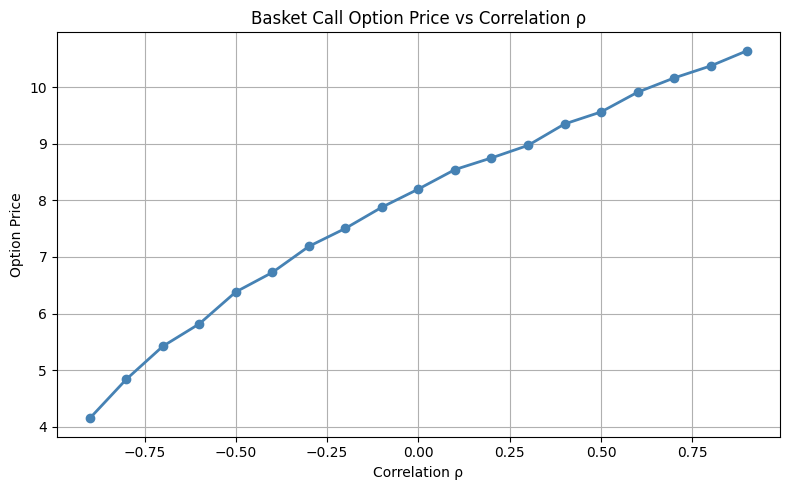

In [ ]:
# Vary rho from -0.9 to 0.9 and plot price

rho_values = np.linspace(-0.9, 0.9, 19)
prices = []

for rho_val in rho_values:
    Z1 = np.random.randn(N)
    Z2 = np.random.randn(N)

    W_A = np.sqrt(T) * Z1
    W_B = np.sqrt(T) * (rho_val * Z1 + np.sqrt(1 - rho_val**2) * Z2)

    ST_A = S0_A * np.exp((r - 0.5 * sigma**2) * T + sigma * W_A)
    ST_B = S0_B * np.exp((r - 0.5 * eta**2)   * T + eta   * W_B)

    payoffs = np.maximum(0.5 * (ST_A + ST_B) - K, 0)
    prices.append(np.exp(-r * T) * np.mean(payoffs))

plt.figure(figsize=(8, 5))
plt.plot(rho_values, prices, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Correlation ρ')
plt.ylabel('Option Price')
plt.title('Basket Call Option Price vs Correlation ρ')
plt.grid(True)
plt.tight_layout()
plt.show()

### **3.5: Results and Discussion**

Using the parameters $S_0^A = S_0^B = 100$, $K = 100$,
$r = 0.02$, $\sigma = 0.2$, $\eta = 0.3$, $\rho = 0.5$,
$T = 1$ and $N = 100000$ simulations, we obtain a
time-0 basket call price of $\hat{V}_0 = 9.6529$.

**3.5.1 Effect of correlation $\rho$ on the option price**

As shown in the plot above, the option price is
**increasing in $\rho$**. This can be understood intuitively
as follows.

The basket payoff depends on the average of the two stock
prices $\frac{1}{2}(S_T^A + S_T^B)$. When $\rho$ is high,
the two stocks tend to move together, meaning the basket
behaves more like a single volatile asset with less
diversification benefit. This increases the variance of
the basket, and since a call option benefits from higher
variance - the upside is unlimited but the downside is
floored at zero - a higher variance translates directly
into a higher option price.

**3.5.2 Variance of the Basket**

To see this more precisely, we can compute the variance
of the basket $\frac{1}{2}(S_T^A + S_T^B)$.
Under the risk-neutral measure, since both stocks follow
GBM, their terminal values are lognormal.
Using the properties of covariance:

$$\text{Var}\left(\frac{1}{2}(S_T^A + S_T^B)\right) =
\frac{1}{4}\left(\text{Var}(S_T^A) + \text{Var}(S_T^B)
+ 2\text{Cov}(S_T^A, S_T^B)\right)$$

Since $\text{Cov}(S_T^A, S_T^B)$ is increasing in $\rho$,
the variance of the basket is also **increasing in $\rho$**:

- When $\rho = -1$: $\text{Cov}(S_T^A, S_T^B)$ is most
negative, basket variance is **minimised**
- When $\rho = 1$: $\text{Cov}(S_T^A, S_T^B)$ is most
positive, basket variance is **maximised**

Since a call option price is increasing in the variance
of the underlying - higher variance means a greater
chance of a large positive payoff - the option price
inherits this monotone increasing relationship with $\rho$.

**3.5.3 Extreme cases**

- When $\rho \to -1$, the two stocks move in perfectly
opposite directions. Gains in one stock are offset by
losses in the other, the basket variance is minimised,
and the option price is at its lowest.

- When $\rho \to 1$, the two stocks move in perfect
lockstep, the basket variance is maximised, and the
option price is at its highest.

**3.5.4 Shape of the curve**

The plot confirms this monotonically increasing
relationship. The curve bends slightly upward rather
than being perfectly linear, consistent with the convex
relationship between option prices and underlying variance.

## Question 4: SDE simulation and option pricing

## **4.0 Introduction and Model Setup**

**4.0.1 Model Specification and Financial Motivation**

In this problem, we consider the numerical approximation of a mean-reverting stock price model, combining features of classical interest rate models with geometric (proportional) volatility. The standard Vasicek interest rate model, which underlies the Ornstein-Uhlenbeck process, specifies:
$$dr_t = \kappa(\theta - r_t)dt + \sigma dW_t$$
The defining feature of this specification is the mean-reverting drift which pulls the process to a fixed level $ \theta $ -  reflecting the empirical observation that many financial quantities (such as short term interest rates and exchange rate spreads) tend to fluctuate around an equilibrium, rather than drifting indefinitely as assumed in simpler models such as geometric Brownian motion. The parameter $\kappa > 0$ governs the speed of mean reversion: it determines how strongly the process is pulled back toward the long-run level $\theta$, with larger values implying faster adjustment to deviations from equilibrium. While the additive diffusion term leads to analytical tractability, it is less suitable for modelling stock prices. In particular, the term $\sigma dW_t$ introduces shocks that are independent of the level of the process and can drive the system below zero with positive probability. Moreover, additive noise treats absolute price movements uniformly across all levels, thereby neglecting the empirical observation that volatility typically scales with the magnitude of the underlying asset. To address such limitations we consider the dynamics:

$\begin{align}
\boldsymbol{
dS_t = \kappa(\theta - S_t)\,dt + \sigma S_t\, dW_t
},
\quad \text{where } \kappa, \theta, \sigma > 0 \text{ and } (W_t)_{t \ge 0} \text{ is a Brownian motion under the risk-neutral measure}
\tag{1}
\end{align} $

(1) incorporates a multiplicative diffusion term of the form $\sigma S_t dW_t$. This specification implies that the magnitude of stochastic fluctuations is proportional to the current level of the process, ensuring that larger values of $S_t$ are associated with higher absolute volatility. This is more consistent with empirical observations in financial markets, where price variability tends to scale with the level of the underlying asset rather than remaining constant.

From a modelling perspective, this structure preserves positivity more naturally than additive noise and aligns more closely with the behaviour of asset prices, which typically exhibit proportional rather than absolute shocks. Consequently, the resulting dynamics combine mean reversion with state-dependent volatility, yielding a richer and more realistic stochastic structure.


**4.0.2 Solution Regularity**

Before constructing a numerical approximation of the process, it is essential to establish that the stochastic differential equation is well-posed, meaning that it admits a unique strong solution. This ensures that the model is mathematically meaningful and that the simulated paths correspond to a properly defined continuous-time stochastic process rather than an ill-posed or ambiguous system. In particular, we verify standard conditions on the drift and diffusion coefficients that guarantee existence and uniqueness of solutions.


For the SDE
$$dS_t = \mu(S_t)dt + \beta(S_t)dW_t, \quad S_0 > 0$$
we define the drift and diffusion coefficients:
$$\mu(s) := \kappa(\theta - s), \quad \beta(s) := \sigma s$$

**Definition 4.0.2.0** (Lipschitz Continuity and Linear Growth). A function $f:\mathbb{R}\to\mathbb{R}$ is *Lipschitz continuous* if there exists a constant $k>0$ such that
$$|f(x)-f(y)|\leq k|x-y| \quad \text{for all } x,y\in\mathbb{R}$$
A function $f:\mathbb{R}\to\mathbb{R}$ has *linear growth* if there exists a constant $k>0$ such that
$$|f(x)|\leq k(1+|x|) \quad \text{for all } x\in\mathbb{R}$$

**Theorem 4.0.2.1** (Existence and Uniqueness of Strong Solutions). If the coefficients $\mu$ and $\beta$ are both Lipschitz continuous and have linear growth, then there exists a unique strong solution $(S_t)_{t \in [0,T]}$ to the SDE with finite second moments.


**Lemma 4.0.2.2** (Lipschitz Continuity of Drift and Diffusion). The coefficients $\mu(s) = \kappa(\theta - s)$ and $\beta(s) = \sigma s$ are Lipschitz continuous.

*Proof.* For any $s_1, s_2 \in \mathbb{R}$:

$$|\mu(s_1) - \mu(s_2)| = |\kappa(\theta - s_1) - \kappa(\theta - s_2)| = \kappa|s_2 - s_1|$$

Therefore $\mu$ is Lipschitz continuous with constant $k = \kappa$.

$$|\beta(s_1) - \beta(s_2)| = |\sigma s_1 - \sigma s_2| = \sigma|s_1 - s_2|$$

Therefore $\beta$ is Lipschitz continuous with constant $k = \sigma$. $\square$

**Lemma 4.0.2.3** (Linear Growth of Drift and Diffusion). The coefficients $\mu(s) = \kappa(\theta - s)$ and $\beta(s) = \sigma s$ have linear growth.

*Proof.* For the drift coefficient, for all $s \in \mathbb{R}$:

$$|\mu(s)| = |\kappa(\theta - s)| \leq \kappa(|\theta| + |s|) = \kappa(\theta + |s|) \leq \kappa(\theta + 1)(1 + |s|)$$

Therefore $\mu$ has linear growth with constant $k = \kappa(\theta + 1)$.

For the diffusion coefficient, for all $s \in \mathbb{R}$:

$$|\beta(s)| = |\sigma s| = \sigma|s| \leq \sigma(1 + |s|)$$

Therefore $\beta$ has linear growth with constant $k = \sigma$. $\square$

**Corollary 4.0.2.4** (Well-Posedness of the Stock Price SDE). By Theorem 4.0.2.1, since the coefficients $\mu$ and $\beta$ satisfy both Lipschitz continuity (Lemma 4.0.2.2) and linear growth (Lemma 4.0.2.3), there exists a unique strong solution $(S_t)_{t \in [0,T]}$ to
$$dS_t = \kappa(\theta - S_t)dt + \sigma S_t dW_t, \quad S_0 > 0$$
This establishes mathematical well-posedness of the problem and provides theoretical justification for the numerical approximation scheme presented in subsequent sections.

## 4.1 Simulation of the SDE via the Euler Scheme

Unlike geometric Brownian motion or the Ornstein–Uhlenbeck process, the SDE given in (1) does not admit a closed-form solution for $S_t$ in terms of $W_t$ -  the interaction between mean-reverting drift and state-dependent diffusion prevents explicit integration. This necessitates a numerical scheme on a finite time horizon $[0,T]$.

To construct a numerical approximation of the process $(S_t)_{t \ge 0}$, we discretise the interval $[0,T]$ using a uniform grid
$$
t_k = kh, \quad k = 0,1,\dots,n, \quad \text{with } T = nh, \; n \in \mathbb{N}.
$$
for a fixed step size $h > 0$.

**Definition 4.1.1 (Euler Scheme):**  
Let $(X_t)_{t \ge 0}$ satisfy an SDE of the form
$$
dX_t = \mu(X_t)\,dt + \beta(X_t)\,dW_t.
$$
The Euler scheme with step size $h > 0$ is the discrete-time process $(X_k)_{k=0}^n$ defined by
$$
X_{k+1} = X_k + \mu(X_k)h + \beta(X_k)\Delta W_k,
$$
where $\Delta W_k := W_{t_{k+1}} - W_{t_k} \sim \mathcal{N}(0,h)$ are independent increments.


Applying Definition 4.1.1 to the present SDE, with
$$
\mu(S_t) = \kappa(\theta - S_t), \quad \beta(S_t) = \sigma S_t,
$$
we obtain the Euler approximation
$$
S_{k+1} = S_k + \kappa(\theta - S_k)h + \sigma S_k \Delta W_k.
$$

Using the representation $\Delta W_k = \sqrt{h}Z_k$, where $Z_k \sim \mathcal{N}(0,1)$ are independent, this can be written as
$$
S_{k+1} = S_k + \kappa(\theta - S_k)h + \sigma S_k \sqrt{h} Z_k. \tag{2}
$$

Starting from the initial value $S_0$, this recursion generates a discrete approximation $(S_0, S_1, \dots, S_n)$ to the continuous-time process on the grid $\{t_k\}_{k=0}^n$.

**4.1.2: Sample paths for $S_T$**

In [ ]:
# Parameters
S0    = 5
kappa = 0.5
theta = 4
sigma = 0.3
T     = 1
h     = 1/250
n     = int(T / h)

# Time grid
t = np.linspace(0, T, n+1)

# Simulate M sample paths
def simulate_paths(M):
    S = np.zeros((M, n+1))
    S[:, 0] = S0
    sqrt_h = np.sqrt(h)

    for k in range(n):
        Z = np.random.normal(0, 1, size=M)
        S[:, k+1] = S[:, k] + kappa*(theta - S[:, k])*h + sigma*S[:, k]*sqrt_h*Z

    return S


**4.1.3: Plot of Sample Paths**

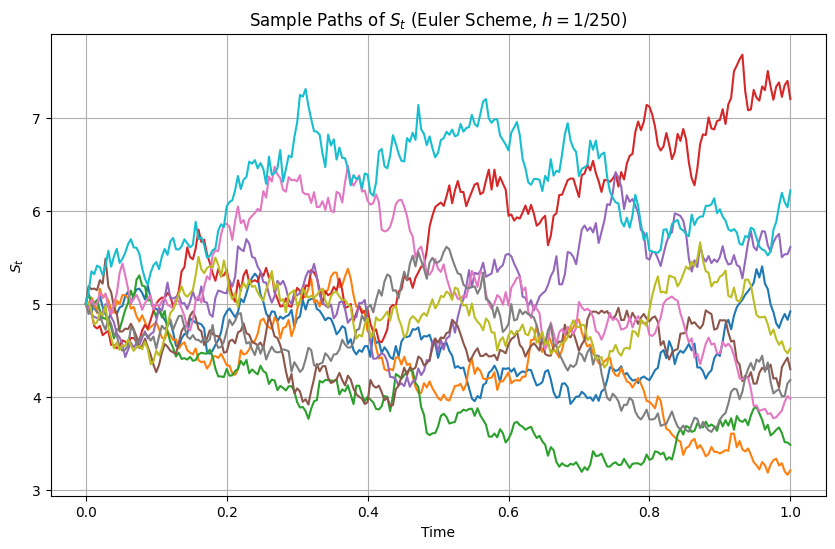

In [ ]:
# Generate 10 sample paths
M = 10
paths = simulate_paths(M)

# Plot
plt.figure(figsize=(10,6))
for i in range(M):
    plt.plot(t, paths[i])

plt.xlabel("Time")
plt.ylabel("$S_t$")
plt.title("Sample Paths of $S_t$ (Euler Scheme, $h = 1/250$)")
plt.grid(True)
plt.show()

**4.1.3 Remark (Convergence of the Euler Scheme):**  
The Euler scheme introduced above provides a discrete-time approximation $(\hat{S}_k)_{k=0}^n$ to the continuous-time process $(S_t)_{t \ge 0}$, whose accuracy depends on the step size $h$.

In the *strong* sense, the scheme has order $\tfrac{1}{2}$, in that
$$
\mathbb{E}\big[|S_T - \hat{S}_T|\big] = O(h^{1/2}) \quad \text{as } h \to 0,
$$
which quantifies the pathwise error.

In the *weak* sense, it has order $1$: for all test functions $g \in C_{pol}^{4}$,
$$
\big|\mathbb{E}[g(S_T)] - \mathbb{E}[g(\hat{S}_T)]\big| = O(h),
$$
as $h \to 0$.

Since the primary objective in what follows is to approximate expectations of functions of $S_T$ (e.g. option payoffs), weak convergence is the relevant notion in this context. In particular, it justifies the use of simulated samples of $\hat{S}_T$ in Monte Carlo estimation.

## 4.2 Monte Carlo estimator for the option price

We consider a European call option with strike $K = 4$ and payoff
$$
H_T = (S_T - 4)^+ \tag{3}
$$

****Theorem 4.1: Feynman-Kac Theorem:**** Under the risk-neutral measure, the time-$0$ price of the option is given by,
$$
V_0 = e^{-rT}\,\mathbb{E}[(S_T - 4)^+].
$$

To approximate this expectation, we simulate $N$ independent samples $(\hat{S}_T^{(i)})_{i=1}^N$ of the terminal value using the Euler scheme. The Monte Carlo estimator of the option price is then:
$$
\hat{V}_0^{(N)} = e^{-rT}\,\frac{1}{N} \sum_{i=1}^N (\hat{S}_T^{(i)} - 4)^+ \tag{4}
$$

**Justification:**  
By construction, the samples $(\hat{S}_T^{(i)})$ are i.i.d. approximations of $S_T$. By the law of large numbers,
$$
\frac{1}{N} \sum_{i=1}^N (\hat{S}_T^{(i)} - 4)^+ \;\xrightarrow{a.s.}\; \mathbb{E}[(\hat{S}_T - 4)^+]
\quad \text{as } N \to \infty.
$$

Furthermore, by weak convergence of the Euler scheme,
$$
\mathbb{E}[(\hat{S}_T - 4)^+] \to \mathbb{E}[(S_T - 4)^+] \quad \text{as } h \to 0.
$$

Therefore, for sufficiently large $N$, the estimator $\hat{V}_0^{(N)}$ provides a consistent approximation of the true option price.
The efficiency of the Monte Carlo estimator can be improved using variance reduction techniques, which aim to reduce the statistical error without increasing the number of simulations. Such methods will be considered in a later section.

## 4.3 Asymptotic Confidence Interval for the Monte Carlo Estimator

To complement the consistency result of Section 4.2, we now quantify the statistical uncertainty of the estimator. Define the discounted payoff of the $i$-th simulated path as
$$
X_i = e^{-rT}(\hat{S}_T^{(i)} - K)^+.
$$

The Monte Carlo estimator can then be written as the sample mean
$$
\overline{V}_N = \frac{1}{N} \sum_{i=1}^N X_i.
$$

**Theorem 4.3.1 (Central Limit Theorem for the Monte Carlo Estimator)**  
Since $(X_i)_{i=1}^N$ are i.i.d. random variables with finite variance $\sigma^2 = \mathrm{Var}(X_1)$, we have
$$
\sqrt{N}\left(\overline{V}_N - \mathbb{E}[X_1]\right)
\;\xrightarrow{d}\;
\mathcal{N}(0, \sigma^2)
\quad \text{as } N \to \infty.
$$

This implies that, for $q_\alpha$ the upper $\alpha$-quantile of the standard normal distribution (with $\alpha = 0.05$ giving $q_\alpha = 1.96$), an asymptotic $(1 - 2\alpha)$ confidence interval for the true option price $V_0$ is given by
\begin{align*}
\left( \overline{V}_N - q_\alpha \frac{\sigma}{\sqrt{N}} ,
\overline{V}_N + q_\alpha \frac{\sigma}{\sqrt{N}} \right).
\end{align*}


In practice, the variance $\sigma^2$ is unknown. We therefore introduce its estimator, which would be used has $\sigma$ not been pre-specified.

**Definition 4.3.2 (Sample Variance)**  
The sample variance of the discounted payoffs is defined as
$$
v_N^2 = \frac{1}{N-1} \sum_{i=1}^N (X_i - \overline{V}_N)^2.
$$

By **Slutsky’s theorem**, replacing $\sigma$ by the consistent estimator $v_N$ preserves the asymptotic normality result. This yields the practically implementable confidence interval

**Proposition 4.3.3 (Asymptotic Confidence Interval)**  
An asymptotically valid $(1 - 2\alpha)$ confidence interval for $V_0$ is given by
$$
\left(\overline{V}_N - q_\alpha \frac{v_N}{\sqrt{N}},\;
\overline{V}_N + q_\alpha \frac{v_N}{\sqrt{N}}\right),
$$
where $q_\alpha = 1.96$ for a 95% confidence interval.

**Remark 4.3.4** The overall numerical error in the pricing procedure consists of two components: the discretisation error arising from the Euler approximation of the SDE (controlled by $h$), and the statistical error arising from Monte Carlo sampling (controlled by $N$). In particular, these errors can be reduced independently by refining the time grid and increasing the number of simulations respectively. In practice, computational resources impose a constraint of the form $N \times n \approx \text{constant}$, where $n = T/h$ denotes the number of time steps per path. This induces a trade-off between increasing the accuracy of individual paths (by decreasing $h$) and reducing statistical error (by increasing $N$).

Balancing these two sources of error leads to an optimal allocation of computational effort, where neither the discretisation error nor the Monte Carlo error dominates. This principle motivates the joint analysis of $N$ and $h$ in numerical experiments.


**Remark 4.3.4 (Error decomposition and computational budget)**  
The overall numerical error of the Monte Carlo pricing procedure consists of two components: the discretisation error induced by the Euler approximation of the SDE (controlled by h) and the statistical error arising from Monte Carlo sampling (controlled by N). These errors can be reduced independently by refining the time grid and increasing the number of simulations respectively. In practice, computational resources impose a constraint of the form $N \times n \approx \text{constant}$, where $n = T/h$ denotes the number of time steps per path. This induces a trade-off between increasing the accuracy of individual paths (by decreasing $h$) and reducing statistical error (by increasing $N$).

Indeed, writing \( n = T/h \), the total computational cost of the simulation satisfies
$$
C(h,N) = O\!\left(\frac{N}{h}\right).
$$

Under such a constraint, reducing the time step $h$ improves the discretisation accuracy but increases computational cost per path, while increasing $N$ reduces statistical error but increases total cost.

As seen in the lecture notes, this leads to a trade-off between bias and variance, and the optimal allocation of computational effort balances the two error contributions. In particular, for the Euler scheme (weak order $\beta = 1$), the resulting optimal convergence rate in terms of computational budget is
$$
\sqrt{\mathrm{MSE}} = O(k^{-1/3}),
$$
which is slower than the pure Monte Carlo rate $O(k^{-1/2})$ due to discretisation error.

This highlights that improving accuracy requires a careful balance between time discretisation and the number of Monte Carlo samples.

Monte Carlo price : 0.77165
Standard error    : 0.00300
95% CI            : [0.7658, 0.7775]


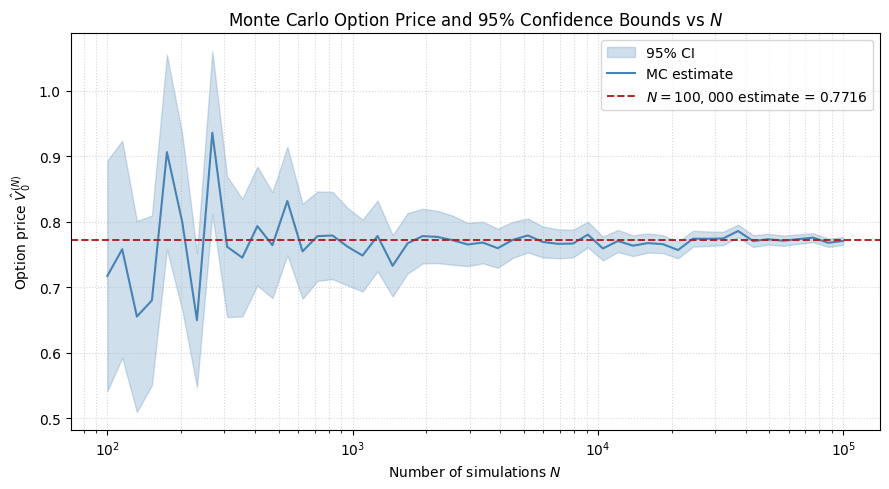

In [ ]:
# Additional Parameters
K     = 4
r     = 0.02

def mc_price(M):
    discounted_payoff = np.exp(-r*T) * np.maximum(simulate_paths(M)[:, -1] - K, 0)
    price = np.mean(discounted_payoff)
    se    = np.std(discounted_payoff, ddof=1) / np.sqrt(M)
    return price, se, price - 1.96*se, price + 1.96*se

# Single run
M = 100_000
price, se, ci_l, ci_u = mc_price(M)
print(f"Monte Carlo price : {price:.5f}")
print(f"Standard error    : {se:.5f}")
print(f"95% CI            : [{ci_l:.4f}, {ci_u:.4f}]")

# CI as a function of N
Ns     = np.logspace(2, 5, 50).astype(int)
result = np.array([mc_price(N) for N in Ns])
prices, _, lower, upper = result.T

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.fill_between(Ns, lower, upper, alpha=0.25, color="steelblue", label="95% CI")
ax.plot(Ns, prices, color="steelblue", lw=1.5,   label="MC estimate")
ax.axhline(price, color="firebrick", lw=1.4, ls="--",
           label=f"$N={M:,}$ estimate = {price:.4f}")

ax.set_xscale("log")
ax.set_xlabel("Number of simulations $N$")
ax.set_ylabel("Option price $\\hat{V}_0^{(N)}$")
ax.set_title("Monte Carlo Option Price and 95% Confidence Bounds vs $N$")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.5)

plt.tight_layout()
plt.show()

## 4.4 Importance Sampling for Variance Reduction

A limitation of the standard Monte Carlo estimator is that its variance may be large when the payoff event is rare. For example, as seen in lectures, the Monte Carlo estimation of $\mu = \mathbb{E}[\mathbf{1}_{\{X \geq 10\}}]$ has relative error of order $100\%$, motivating a change of measure to shift probability mass toward the important region and improve sampling efficiency. This phenomenon is particularly relevant for out-of-the-money options, where many simulated paths contribute little or zero payoff, making the estimator inefficient.

To address this, we employ importance sampling via a change of measure. Under the risk-neutral measure $\mathbb{Q}$, the stock dynamics satisfy

$$
dS_t = \kappa(\theta - S_t)\,dt + \sigma S_t\,dW_t.
$$

We introduce a shifted probability measure $\mathbb{Q}^{\lambda}$ by defining

$$
dW_t^{\lambda} = dW_t - \lambda\,dt, \tag{5}
$$

for some constant parameter $\lambda \in \mathbb{R}$. Equivalently, $dW_t = dW_t^{\lambda} + \lambda\,dt$. Substituting into the original SDE yields the shifted dynamics

$$
dS_t = \bigl(\kappa(\theta - S_t) + \sigma\lambda S_t\bigr)\,dt + \sigma S_t\,dW_t^{\lambda}.
$$

Observe that the drift remains linear in $S_t$ under $\mathbb{Q}^{\lambda}$, with the effective mean-reversion rate modified from $\kappa$ to $\kappa - \sigma\lambda$:

$$
\kappa(\theta - S_t) + \sigma\lambda S_t = \kappa\theta - (\kappa - \sigma\lambda)S_t.
$$

We restrict attention to $\lambda < \kappa/\sigma$ to ensure the mean-reversion remains positive and the process does not become explosive. Within this range, taking $\lambda > 0$ reduces the effective mean-reversion strength, shifting the terminal distribution rightward and increasing the frequency of paths that finish in-the-money.

By **Girsanov's theorem**, the Radon–Nikodym derivative associated with the measure change from $\mathbb{Q}$ to $\mathbb{Q}^{\lambda}$ is

$$
L_T = \frac{d\mathbb{Q}^{\lambda}}{d\mathbb{Q}} = \exp\!\left(\lambda W_T - \tfrac{1}{2}\lambda^2 T\right). \tag{6}
$$

Since $W_T = W_T^{\lambda} + \lambda T$, substituting gives

$$
\frac{d\mathbb{Q}^{\lambda}}{d\mathbb{Q}} = \exp\!\left(\lambda W_T^{\lambda} + \tfrac{1}{2}\lambda^2 T\right),
$$

and therefore the inverse Radon–Nikodym derivative is

$$
\frac{d\mathbb{Q}}{d\mathbb{Q}^{\lambda}} = \exp\!\left(-\lambda W_T^{\lambda} - \tfrac{1}{2}\lambda^2 T\right).
$$

Applying the change-of-measure identity

$$
\mathbb{E}^{\mathbb{Q}}[X] = \mathbb{E}^{\mathbb{Q}^{\lambda}}\!\left[X \,\frac{d\mathbb{Q}}{d\mathbb{Q}^{\lambda}}\right],
$$

the option price admits the representation

$$
V_0 = e^{-rT}\,\mathbb{E}^{\mathbb{Q}^{\lambda}}\!\left[(S_T - K)^+\exp\!\left(-\lambda W_T^{\lambda} - \tfrac{1}{2}\lambda^2 T\right)\right].
$$

This leads to the importance-sampling estimator

$$
\hat{V}_{\mathrm{IS}}^{(N)} = e^{-rT}\frac{1}{N}\sum_{i=1}^N (S_T^{(i)} - K)^+\exp\!\left(-\lambda W_T^{\lambda,(i)} - \tfrac{1}{2}\lambda^2 T\right), \tag{7}
$$

where the paths $S_T^{(i)}$ are simulated under the shifted measure $\mathbb{Q}^{\lambda}$. The parameter $\lambda$ is selected numerically by minimising the sample variance of the weighted payoffs across a pilot simulation, as described in the following section.

#### 4.4.1 Pilot Simulation to Tune $\lambda$

A practical method for selecting $\lambda$ is to perform a **pilot simulation** under a range of candidate shifted measures and estimate the resulting sample variances of the importance-sampling estimator.

More precisely, define the weighted payoff

$$
Y^{(\lambda)}
=
(S_T - K)^+
\exp\!\left(
-\lambda W_T^{\lambda}
-
\tfrac{1}{2}\lambda^2 T
\right),
$$

which arises from applying the Radon–Nikodym correction $\frac{d\mathbb{Q}}{d\mathbb{Q}^{\lambda}}$ under the shifted measure $\mathbb{Q}^{\lambda}$, consistent with equation (7).

For a collection of candidate parameters $\lambda_1, \lambda_2, \ldots, \lambda_m$, we simulate a moderate number $M$ of paths under each shifted measure and compute the empirical variance

$$
\widehat{\mathrm{Var}}_{\lambda_j}(Y)
=
\frac{1}{M-1}
\sum_{i=1}^{M}
\left(
Y_i^{(\lambda_j)}
-
\overline{Y}^{(\lambda_j)}
\right)^2,
\qquad
\overline{Y}^{(\lambda_j)}
=
\frac{1}{M}
\sum_{i=1}^{M}
Y_i^{(\lambda_j)}.
$$

The optimal parameter $\lambda^{\ast}$ is then selected as

$$
\lambda^{\ast}
=
\operatorname*{arg\,min}_{\lambda_j}
\,
\widehat{\mathrm{Var}}_{\lambda_j}(Y),
$$

and is subsequently used in the final large-scale Monte Carlo simulation.

Since the importance-sampling estimator is unbiased for all $\lambda < \kappa/\sigma$, minimising the sample variance is equivalent to minimising the second moment of the weighted payoff. The pilot simulation identifies the shifted measure that best balances two competing effects: increasing the frequency of paths contributing significantly to the payoff, while keeping the Radon–Nikodym weights sufficiently stable. Excessively large values of $\lambda$ may cause the weights to become highly volatile, offsetting the gains from the measure shift and potentially increasing variance relative to standard Monte Carlo.


**Note:** This methodology follows from Monte Carlo Methods in Financial Engineering* (2004). In lectures, importance sampling was introduced through the selection of a candidate density $g$ used to construct the estimator
$$
\mu_{\mathrm{IS}}
=
\frac1N
\sum_{i=1}^N
h(X_i)\frac{f(X_i)}{g(X_i)},
\qquad X_i \sim g.
$$

The discussion above provides a practical motivation for such a choice. In particular, the shifted measure $\mathbb{Q}^{\lambda}$ plays the role of the candidate sampling distribution $g$, while the original risk-neutral measure $\mathbb{Q}$ corresponds to the target distribution $f$.

Optimal lambda       : 1.062
Weight CV at lambda* : 1.462
Variance reduction   : 88.7%


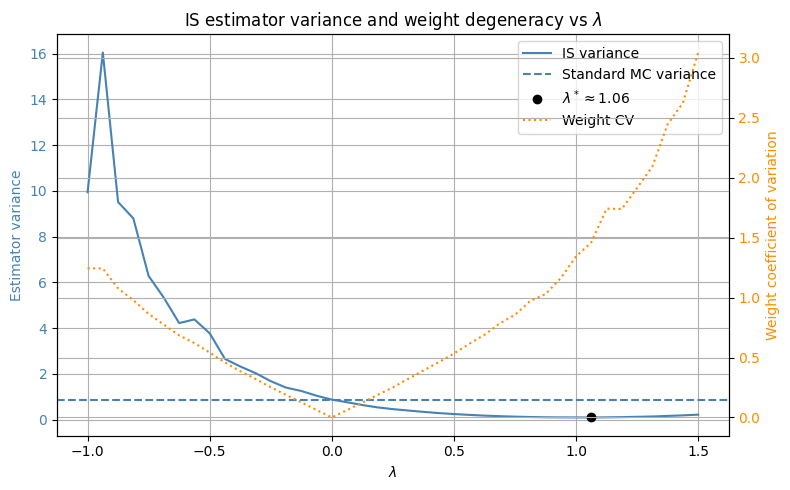

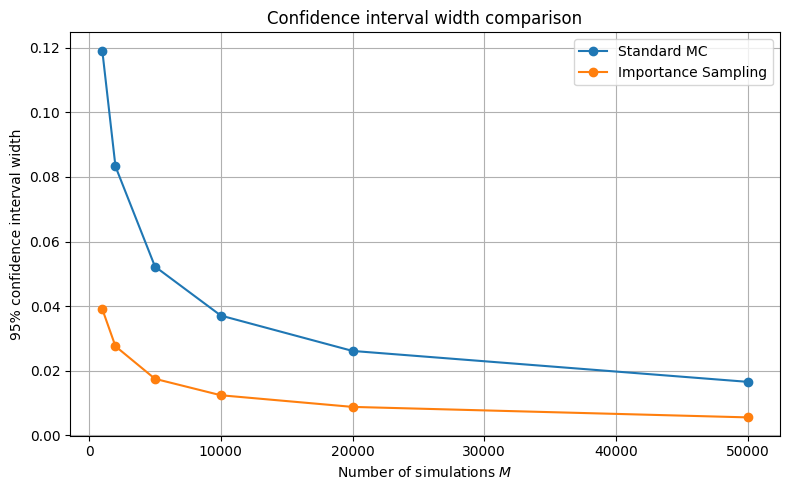

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng_pilot   = np.random.default_rng(seed=100)
rng_compare = np.random.default_rng(seed=200)

sqrt_h = np.sqrt(h)

def MC_estimator(M, rng):
    S = np.full(M, S0, dtype=float)
    for _ in range(n):
        Z  = rng.standard_normal(size=M)
        dW = sqrt_h * Z
        S  = S + kappa * (theta - S) * h + sigma * S * dW
    payoff = np.exp(-r * T) * np.maximum(S - K, 0)
    return np.mean(payoff), np.var(payoff, ddof=1)

# Shifted paths under Q^lambda
def simulate_paths_shifted(M, lam, rng):
    S          = np.full(M, S0, dtype=float)
    W_lambda_T = np.zeros(M)
    for _ in range(n):
        Z          = rng.standard_normal(size=M)
        dW_lambda  = sqrt_h * Z
        W_lambda_T += dW_lambda
        S = (
            S
            + (kappa * (theta - S) + sigma * lam * S) * h
            + sigma * S * dW_lambda
        )
    return S, W_lambda_T

# IS estimator
def IS_estimator(M, lam, rng):
    S_T, W_lambda_T = simulate_paths_shifted(M, lam, rng)
    weights   = np.exp(-lam * W_lambda_T - 0.5 * lam**2 * T)
    weight_cv = np.std(weights, ddof=1) / np.mean(weights)
    payoff    = np.exp(-r * T) * np.maximum(S_T - K, 0) * weights
    return np.mean(payoff), np.var(payoff, ddof=1), weight_cv

# Pilot simulation
lambda_max = kappa / sigma
lambdas    = np.linspace(-1, min(1.5, lambda_max - 0.05), 41)
M_pilot    = 20_000

is_vars, is_cvs = [], []

for lam in lambdas:
    _, var_is, cv_is = IS_estimator(M_pilot, lam, rng_pilot)
    is_vars.append(var_is)
    is_cvs.append(cv_is)

is_vars = np.array(is_vars)
is_cvs  = np.array(is_cvs)

_, mc_var   = MC_estimator(M_pilot, rng_pilot)
lambda_star = lambdas[np.argmin(is_vars)]

print(f"Optimal lambda       : {lambda_star:.3f}")
print(f"Weight CV at lambda* : {is_cvs[np.argmin(is_vars)]:.3f}")
print(f"Variance reduction   : {100*(mc_var - is_vars.min())/mc_var:.1f}%")


# Plot: variance and weight CV vs lambda
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(lambdas, is_vars, color='steelblue', label='IS variance')
ax1.axhline(mc_var,      linestyle='--', color='steelblue',
            label='Standard MC variance')
ax1.plot(lambda_star, is_vars[np.argmin(is_vars)], 'ko', markersize=6,
         label=fr'$\lambda^* \approx {lambda_star:.2f}$' )
ax1.set_xlabel(r'$\lambda$')
ax1.set_ylabel('Estimator variance', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(lambdas, is_cvs, color='darkorange', linestyle=':',
         label='Weight CV')
ax2.set_ylabel('Weight coefficient of variation', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title(r'IS estimator variance and weight degeneracy vs $\lambda$')
ax1.grid(True)
plt.tight_layout()
plt.savefig('variance_vs_lambda.png', dpi=150)
plt.show()


# CI width comparison
# averaged over R replications
M_values = [1000, 2000, 5000, 10000, 20000, 50000]
R        = 10

mc_ci_widths, is_ci_widths = [], []

for M in M_values:
    mc_reps, is_reps = [], []
    for _ in range(R):
        _, mc_var_rep        = MC_estimator(M, rng_compare)
        _, is_var_rep, _     = IS_estimator(M, lambda_star, rng_compare)
        mc_reps.append(2 * 1.96 * np.sqrt(mc_var_rep / M))
        is_reps.append(2 * 1.96 * np.sqrt(is_var_rep / M))
    mc_ci_widths.append(np.mean(mc_reps))
    is_ci_widths.append(np.mean(is_reps))

plt.figure(figsize=(8, 5))
plt.plot(M_values, mc_ci_widths, marker='o', label='Standard MC')
plt.plot(M_values, is_ci_widths, marker='o', label='Importance Sampling')
plt.xlabel('Number of simulations $M$')
plt.ylabel('95% confidence interval width')
plt.title('Confidence interval width comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ci_width_comparison.png', dpi=150)
plt.show()

**4.4.2 Discussion:** The numerical study investigates the effect of the shift parameter λ on the performance of the importance sampling estimator relative to standard Monte Carlo.

The results show a strongly non-linear dependence of estimator variance on λ. For negative values of λ, the variance is significantly larger than that of standard Monte Carlo, indicating that shifting the drift in the “wrong” direction moves probability mass away from the payoff-relevant region and leads to inefficient sampling. In this regime, the estimator performs worse than the baseline method.

As λ increases, the variance decreases rapidly and eventually falls below the standard Monte Carlo benchmark. The variance curve attains a clear minimum at approximately λ\* ≈ 1.06, where the importance sampling estimator achieves its optimal efficiency. At this point, the variance reduction relative to standard Monte Carlo is approximately 88.7%, demonstrating a substantial gain in simulation efficiency.

We include the **coefficient of variation of the importance weights** as a diagnostic for the stability of the change of measure.

In importance sampling, efficiency depends not only on reducing variance of the weighted payoff, but also on preventing the Radon–Nikodym weights from becoming highly uneven. If a small number of paths carry disproportionately large weights while most contribute negligibly, the estimator effectively relies on a very small “effective sample size”, leading to instability and loss of variance reduction benefits. This is known as weight degeneracy. The coefficient of variation of the importance weights is minimised at λ=0, where no change of measure is applied. This is expected, since in this case all Radon–Nikodym weights are identically equal to one, eliminating any dispersion.

As λ moves away from zero in either direction, the likelihood ratios become increasingly variable, leading to growing weight dispersion and hence weight degeneracy. The optimal variance-reducing parameter λ\*≈1.06 still exhibits a relatively high level of weight dispersion. This indicates that the improvement in estimator efficiency is achieved despite noticeable weight degeneracy.

Moreover, the importance sampling estimator consistently produces significantly narrower confidence intervals for the same computational budget. This reduction in width reflects the substantial variance decrease achieved through the change of measure, as the shifted dynamics increase the proportion of paths contributing meaningfully to the payoff. Importantly, the narrowing of confidence intervals is not uniform across all sample sizes: for smaller M, both estimators exhibit noticeable Monte Carlo noise, but the importance sampling estimator stabilises more rapidly as M increases. This indicates a higher effective sample efficiency, consistent with the observed variance reduction of approximately 88.7%.

## 4.5 Convergence Analysis of Higher-Order Numerical Schemes

### 4.5.1 Motivation

In Section 4.1, the Euler discretisation was introduced as a numerical approximation of the stochastic differential equation

$$
dS_t = \kappa(\theta - S_t)\,dt + \sigma S_t\,dW_t.
$$

The Euler scheme is widely used due to its simplicity and its first-order accuracy in the weak sense. However, when higher precision is required - particularly for the estimation of expectations or the approximation of individual sample paths - more sophisticated discretisation methods can offer substantial improvements in accuracy for a given computational cost.

The aim of this section is to investigate three refinements of the Euler scheme:

1. **Milstein scheme**;
2. **Richardson extrapolation applied to the Euler scheme**;
3. **Simplified weak second-order Euler scheme**.

These schemes are designed to improve different aspects of the numerical approximation. The Milstein scheme includes an additional correction term from the stochastic Taylor expansion, thereby increasing the pathwise accuracy of the approximation. Richardson extrapolation and the weak second-order scheme, by contrast, are constructed to reduce the leading-order discretisation bias in expectations and are therefore particularly well suited to Monte Carlo pricing applications.

### 4.5.2 Scheme Definitions

The **Euler scheme** is given by
$$
\hat{S}_{(i+1)h} = \hat{S}_{ih} + \kappa(\theta - \hat{S}_{ih})\,h + \sigma \hat{S}_{ih}\,(W_{(i+1)h} - W_{ih}).
$$

The **Milstein scheme** appends a correction term from the stochastic Taylor expansion. For general drift $\mu$ and diffusion $\sigma$, it is defined by $\hat{S}_0 = S_0$ and
$$
\hat{S}_{(i+1)h}
=
\hat{S}_{ih}
+ \mu(\hat{S}_{ih})\,h
+ \sigma(\hat{S}_{ih})\,(W_{(i+1)h} - W_{ih})
+ \tfrac{1}{2}\,\sigma'(\hat{S}_{ih})\,\sigma(\hat{S}_{ih})
\bigl((W_{(i+1)h} - W_{ih})^2 - h\bigr),
\quad i = 0,1,2,\ldots
$$
For the SDE at hand, $\mu(x) = \kappa(\theta-x)$, $\sigma(x) = \sigma x$, $\sigma'(x) = \sigma$, so the correction reduces to $\tfrac{1}{2}\sigma^2\hat{S}_{ih}\bigl((W_{(i+1)h}-W_{ih})^2-h\bigr)$.

**Richardson extrapolation** is not a separate scheme but a post-processing step. Using the Euler weak error expansion $\mathbb{E}[f(\hat{S}_T^h)] = \mathbb{E}[f(S_T)] + C_1 h + O(h^2)$, the estimator
$$
2\,\mathbb{E}\bigl[f(\hat{S}_T^{h/2})\bigr] - \mathbb{E}\bigl[f(\hat{S}_T^h)\bigr]
$$
cancels the $O(h)$ term, yielding weak order 2.

The **simplified weak second-order Euler scheme** is defined by $\hat{S}_0 = S_0$ and

$$
\begin{aligned}
\hat{S}_{(i+1)h}
={}&
\hat{S}_{ih}
+ \mu(\hat{S}_{ih})\,h
+ \sigma(\hat{S}_{ih})\,\Delta\widehat{W}_{i+1}(h)
+ \tfrac{1}{2}\sigma'(\hat{S}_{ih})\,\sigma(\hat{S}_{ih})
\bigl((\Delta\widehat{W}_{i+1}(h))^2 - h\bigr) \\
&+ \tfrac{1}{2}\!\left(\mu'(\hat{S}_{ih})\,\mu(\hat{S}_{ih})
+ \tfrac{1}{2}\mu''(\hat{S}_{ih})\,\sigma(\hat{S}_{ih})^2\right)h^2 \\
&+ \tfrac{1}{2}\!\left(\sigma'(\hat{S}_{ih})\,\mu(\hat{S}_{ih})
+ \tfrac{1}{2}\sigma''(\hat{S}_{ih})\,\sigma(\hat{S}_{ih})^2\right)
h\,\Delta\widehat{W}_{i+1}(h),
\qquad i = 0,1,2,\ldots
\end{aligned}
$$

where $(\Delta\widehat{W}_i(h))_{i=1}^\infty$ are i.i.d. random variables satisfying, for some constant $k > 0$,

$$
\left|\mathbb{E}[\Delta\widehat{W}_i(h)]\right|
+ \left|\mathbb{E}[\Delta\widehat{W}_i(h)^3]\right|
+ \left|\mathbb{E}[\Delta\widehat{W}_i(h)^5]\right|
\leq kh^3,
$$

$$
\left|\mathbb{E}[\Delta\widehat{W}_i(h)^2] - h\right|
+ \left|\mathbb{E}[\Delta\widehat{W}_i(h)^4] - 3h^2\right|
\leq kh^3.
$$

These moment conditions ensure the increments approximate $\mathcal{N}(0,h)$ to sufficient order for weak second-order accuracy; the canonical choice is $\Delta\widehat{W}_i(h) = \pm\sqrt{h}$ with equal probability.

### 4.5.3 Convergence

The theoretical orders are:

| Scheme | Weak order | Strong order |
|---|---|---|
| Euler | 1 | $\tfrac{1}{2}$ |
| Milstein | 1 | $1$ |
| Richardson extrapolation | 2 | $\tfrac{1}{2}$ |
| Weak second-order | 2 | $\tfrac{1}{2}$ |

**Weak convergence** of order $\beta$ requires
$$
\left|\mathbb{E}\bigl[f(\hat{S}_T^h)\bigr] - \mathbb{E}\bigl[f(S_T)\bigr]\right| = O(h^\beta), \qquad h\downarrow 0,
$$
for $f \in C_{\mathrm{pol}}^{2(\beta+1)}$. The test function $f(x) = x$ is used, with exact value $\mathbb{E}[S_T] = \theta + (S_0-\theta)e^{-\kappa T}$.

**Strong convergence** of order $\gamma$ requires
$$
\mathbb{E}\bigl[|\hat{S}_T^h - S_T|\bigr] = O(h^\gamma), \qquad h\downarrow 0.
$$
Since $S_T$ has no closed form, a reference solution at step size $h_{\mathrm{ref}} = 2^{-12}$ is used. The same Brownian paths are shared between the reference and coarse approximations to minimise variance in the error estimate.

### 4.5.4 Methodology

#### 4.5.4.1 Weak Convergence Analysis

For each scheme and each step size $h \in \{2^{-2}, 2^{-3}, \ldots, 2^{-7}\}$, the weak convergence study proceeds as follows:

1. Simulate $N$ independent terminal values $\hat{S}_T^{h,(1)}, \ldots, \hat{S}_T^{h,(N)}$.
2. Compute the Monte Carlo estimate
$$
\widehat{\mathbb{E}}\bigl[\hat{S}_T^h\bigr]
=
\frac{1}{N}\sum_{i=1}^N \hat{S}_T^{h,(i)}.
$$
3. Measure the weak error
$$
\varepsilon_{\mathrm{weak}}(h)
=
\left|\widehat{\mathbb{E}}\bigl[\hat{S}_T^h\bigr] - \mathbb{E}[S_T]\right|,
$$
where $\mathbb{E}[S_T]$ is given by equation (8).

Repeating this procedure across the prescribed step sizes allows the empirical weak order of convergence to be estimated from the slope of the log-log plot of $\varepsilon_{\mathrm{weak}}(h)$ against $h$.

#### 4.5.4.2 Strong Convergence Analysis

The strong convergence study is carried out for the Euler, Milstein, and weak second-order schemes. Richardson extrapolation is excluded, since it is designed to improve weak accuracy rather than pathwise approximation.

For each step size $h$, the procedure is:

1. Generate Brownian increments on a fine grid with step size $h_{\mathrm{ref}}$.
2. Compute a reference solution $S_T^{\mathrm{ref}}$ using the Euler scheme on this grid.
3. Aggregate the fine increments to construct Brownian increments corresponding to step size $h$.
4. Simulate the approximation $\hat{S}_T^h$ using these aggregated increments.
5. Compute the strong error
$$
\varepsilon_{\mathrm{strong}}(h)
=
\frac{1}{N}\sum_{i=1}^N
\left|\hat{S}_T^{h,(i)} - S_T^{\mathrm{ref},(i)}\right|.
$$

Since $S_T$ is not available in closed form, the fine-grid approximation $S_T^{\mathrm{ref}}$ serves as a proxy for the true solution; taking $h_{\mathrm{ref}}$ sufficiently small ensures the reference discretisation error is negligible relative to the errors being measured. Sharing the same underlying Brownian paths across both approximations ensures the estimated strong error reflects only the discretisation error of the scheme, while substantially reducing Monte Carlo noise.

In [ ]:
# Terminal-value simulators

def euler_terminal(h, M, rng):
    """
    Euler-Maruyama: S_{(i+1)h} = S_{ih} + kappa*(theta-S)*h + sigma*S*dW
    """
    n      = int(T / h)
    sqrt_h = np.sqrt(h)
    S      = np.full(M, S0, dtype=float)
    for _ in range(n):
        dW = sqrt_h * rng.standard_normal(M)
        S += kappa * (theta - S) * h + sigma * S * dW
    return S


def milstein_terminal(h, M, rng):
    """
    Milstein: Euler + 0.5*sigma^2*S*(dW^2 - h)
    """
    n      = int(T / h)
    sqrt_h = np.sqrt(h)
    S      = np.full(M, S0, dtype=float)
    for _ in range(n):
        dW = sqrt_h * rng.standard_normal(M)
        S += (
            kappa * (theta - S) * h
            + sigma * S * dW
            + 0.5 * sigma**2 * S * (dW**2 - h)
        )
    return S


def richardson_terminal(h, M, rng):
    """
    Richardson extrapolation: 2*Euler(h/2) - Euler(h).
    Fine and coarse paths share the same Brownian increments
    via dW = dW1 + dW2 (variance reduction by coupling).
    """
    n        = int(T / h)
    h2       = h / 2.0
    sqrt_h2  = np.sqrt(h2)
    S_coarse = np.full(M, S0, dtype=float)
    S_fine   = np.full(M, S0, dtype=float)
    for _ in range(n):
        dW1 = sqrt_h2 * rng.standard_normal(M)
        dW2 = sqrt_h2 * rng.standard_normal(M)
        dW  = dW1 + dW2
        S_coarse += kappa * (theta - S_coarse) * h  + sigma * S_coarse * dW
        S_fine   += kappa * (theta - S_fine)   * h2 + sigma * S_fine   * dW1
        S_fine   += kappa * (theta - S_fine)   * h2 + sigma * S_fine   * dW2
    # Combine MEANS not individual paths - correct statistical implementation
    return S_coarse, S_fine   # return both; weak error computed in cell 3


def weak2_terminal(h, M, rng):
    """
    Simplified weak second-order scheme.
    Two-point increment via thresholding a standard normal - consumes
    exactly n standard_normal(M) calls, same as Euler/Milstein.

    For this SDE: mu'=-kappa, mu''=0, sigma'=sigma, sigma''=0:
        (i)   mu*h
        (ii)  sigma*S*dW
        (iii) 0.5*sigma^2*S*(dW^2-h)
        (iv)  0.5*(-kappa)*mu*h^2
        (v)   0.5*sigma*mu*h*dW
    """
    n      = int(T / h)
    sqrt_h = np.sqrt(h)
    S      = np.full(M, S0, dtype=float)
    for _ in range(n):
        Z  = rng.standard_normal(M)
        dW = sqrt_h * np.where(Z >= 0, 1.0, -1.0)
        mu = kappa * (theta - S)
        S += (
            mu * h
            + sigma * S * dW
            + 0.5 * sigma**2 * S * (dW**2 - h)
            + 0.5 * (-kappa) * mu * h**2
            + 0.5 * sigma * mu * h * dW
        )
    return S


def weak2_gaussian_terminal(h, M, rng):
    """
    Weak second-order scheme with Gaussian increments.
    Used in the strong convergence study only, where increments
    must be aggregated from the fine reference grid.
    """
    n      = int(T / h)
    sqrt_h = np.sqrt(h)
    S      = np.full(M, S0, dtype=float)
    for _ in range(n):
        dW = sqrt_h * rng.standard_normal(M)
        mu = kappa * (theta - S)
        S += (
            mu * h
            + sigma * S * dW
            + 0.5 * sigma**2 * S * (dW**2 - h)
            + 0.5 * (-kappa) * mu * h**2
            + 0.5 * sigma * mu * h * dW
        )
    return S


print("Terminal-value simulators defined.")

Terminal-value simulators defined.


Weak convergence done.
  h = 0.2500 done.
  h = 0.1250 done.
  h = 0.0625 done.
  h = 0.0312 done.
  h = 0.0156 done.
  h = 0.0078 done.
Strong convergence done.


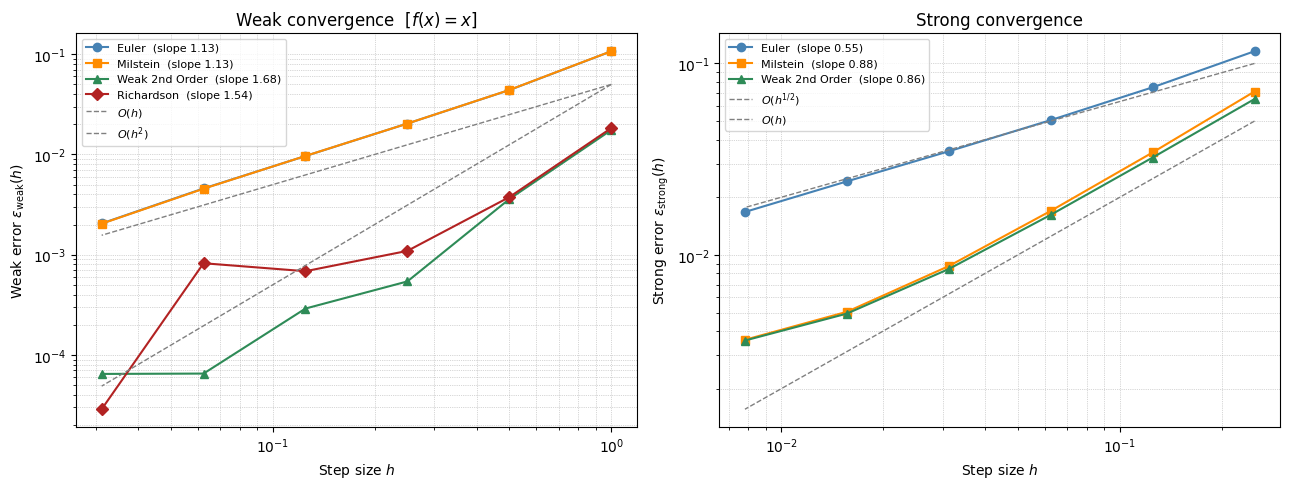


Empirical weak convergence orders:
  Euler                 1.125
  Milstein              1.128
  Weak 2nd Order        1.676
  Richardson            1.538

Empirical strong convergence orders:
  Euler                 0.554
  Milstein              0.880
  Weak 2nd Order        0.858


In [ ]:
step_sizes_weak   = np.array([2**(-k) for k in range(0, 6)])   # 1, 1/2, ..., 2^-5
step_sizes_strong = np.array([2**(-k) for k in range(2, 8)])   # 2^-2, ..., 2^-7

N_weak   = 10_000_000
N_strong =    50_000

E_exact = theta + (S0 - theta) * np.exp(-kappa * T)
f       = lambda S: S

weak_schemes = ["Euler", "Milstein", "Weak 2nd Order", "Richardson"]
weak_errors  = {name: [] for name in weak_schemes}

for h in step_sizes_weak:
    for name, fn in [("Euler",         euler_terminal),
                     ("Milstein",      milstein_terminal),
                     ("Weak 2nd Order", weak2_terminal)]:
        rng = np.random.default_rng(seed=0)
        S_T = fn(h, N_weak, rng)
        weak_errors[name].append(np.abs(np.mean(f(S_T)) - E_exact))

    rng              = np.random.default_rng(seed=1)
    S_coarse, S_fine = richardson_terminal(h, N_weak, rng)
    est              = 2.0 * np.mean(f(S_fine)) - np.mean(f(S_coarse))
    weak_errors["Richardson"].append(np.abs(est - E_exact))

print("Weak convergence done.")

# STRONG CONVERGENCE
strong_schemes = ["Euler", "Milstein", "Weak 2nd Order"]
strong_errors  = {name: [] for name in strong_schemes}

h_ref    = 2**(-12)
sqrt_ref = np.sqrt(h_ref)

for h in step_sizes_strong:
    ratio = int(round(h / h_ref))
    n     = int(T / h)

    rng    = np.random.default_rng(seed=0)
    S_ref  = np.full(N_strong, S0, dtype=float)
    S_eul  = np.full(N_strong, S0, dtype=float)
    S_mils = np.full(N_strong, S0, dtype=float)
    S_w2   = np.full(N_strong, S0, dtype=float)

    for i in range(n):
        dW_block = sqrt_ref * rng.standard_normal((N_strong, ratio))

        for j in range(ratio):
            S_ref += (kappa * (theta - S_ref) * h_ref
                      + sigma * S_ref * dW_block[:, j])

        dW = dW_block.sum(axis=1)

        S_eul += kappa * (theta - S_eul) * h + sigma * S_eul * dW

        S_mils += (kappa * (theta - S_mils) * h
                   + sigma * S_mils * dW
                   + 0.5 * sigma**2 * S_mils * (dW**2 - h))

        mu = kappa * (theta - S_w2)
        S_w2 += (mu * h
                 + sigma * S_w2 * dW
                 + 0.5 * sigma**2 * S_w2 * (dW**2 - h)
                 + 0.5 * (-kappa) * mu * h**2
                 + 0.5 * sigma * mu * h * dW)

    strong_errors["Euler"].append(np.mean(np.abs(S_eul  - S_ref)))
    strong_errors["Milstein"].append(np.mean(np.abs(S_mils - S_ref)))
    strong_errors["Weak 2nd Order"].append(np.mean(np.abs(S_w2  - S_ref)))

    print(f"  h = {h:.4f} done.")

print("Strong convergence done.")

# EMPIRICAL CONVERGENCE ORDERS
log_h_weak   = np.log(step_sizes_weak)
log_h_strong = np.log(step_sizes_strong)

weak_orders   = {}
strong_orders = {}

for name in weak_schemes:
    slope, _ = np.polyfit(log_h_weak, np.log(weak_errors[name]), 1)
    weak_orders[name] = slope

for name in strong_schemes:
    slope, _ = np.polyfit(log_h_strong, np.log(strong_errors[name]), 1)
    strong_orders[name] = slope

# PLOTS
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

markers    = ["o", "s", "^", "D"]
colors     = ["steelblue", "darkorange", "seagreen", "firebrick"]
ref_styles = dict(color="grey", linewidth=1, linestyle="--")

ax = axes[0]
for name, col, mk in zip(weak_schemes, colors, markers):
    ax.loglog(step_sizes_weak, weak_errors[name], marker=mk, color=col,
              linewidth=1.5, label=f"{name}  (slope {weak_orders[name]:.2f})")
ax.loglog(step_sizes_weak, 5e-2 * step_sizes_weak**1, **ref_styles, label="$O(h)$")
ax.loglog(step_sizes_weak, 5e-2 * step_sizes_weak**2, **ref_styles, label="$O(h^2)$")
ax.set_xlabel("Step size $h$")
ax.set_ylabel("Weak error $\\varepsilon_{\\mathrm{weak}}(h)$")
ax.set_title("Weak convergence  [$f(x) = x$]")
ax.legend(fontsize=8)
ax.grid(True, which="both", linestyle=":", linewidth=0.5)

ax = axes[1]
for name, col, mk in zip(strong_schemes, colors, markers):
    ax.loglog(step_sizes_strong, strong_errors[name], marker=mk, color=col,
              linewidth=1.5, label=f"{name}  (slope {strong_orders[name]:.2f})")
ax.loglog(step_sizes_strong, 2e-1 * step_sizes_strong**0.5, **ref_styles, label="$O(h^{1/2})$")
ax.loglog(step_sizes_strong, 2e-1 * step_sizes_strong**1,   **ref_styles, label="$O(h)$")
ax.set_xlabel("Step size $h$")
ax.set_ylabel("Strong error $\\varepsilon_{\\mathrm{strong}}(h)$")
ax.set_title("Strong convergence")
ax.legend(fontsize=8)
ax.grid(True, which="both", linestyle=":", linewidth=0.5)

plt.tight_layout()
plt.savefig("convergence_plots.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nEmpirical weak convergence orders:")
for name in weak_schemes:
    print(f"  {name:<20s}  {weak_orders[name]:.3f}")

print("\nEmpirical strong convergence orders:")
for name in strong_schemes:
    print(f"  {name:<20s}  {strong_orders[name]:.3f}")

## 4.5.5 Interpretation of Numerical Results

### Weak Convergence

| Scheme | Theoretical Order | Empirical Order |
|------|------:|------:|
| Euler-Maruyama | 1 | 1.125 |
| Milstein | 1 | 1.128 |
| Weak Second-Order Euler | 2 | 1.676 |
| Richardson Extrapolation | 2 | 1.538 |

The Euler-Maruyama and Milstein schemes both achieved empirical weak convergence orders very close to 1, in agreement with the theoretical prediction. This confirms that the Milstein correction term, although highly effective in reducing pathwise error, does not alter the leading-order weak bias.

The simplified weak second-order Euler scheme and Richardson extrapolation both produced substantially steeper slopes than Euler and Milstein, demonstrating a clear improvement in weak accuracy. Their empirical orders of 1.676 and 1.538, respectively, are below the theoretical value of 2, but still indicate a significant reduction in bias.

The lower-than-expected orders are primarily due to the fact that both methods remove the dominant $O(h)$ weak error term, leaving a much smaller residual bias. As a result, the discretisation error quickly becomes comparable to the Monte Carlo sampling error, even when using ($10^7$ ) simulations. Richardson extrapolation is especially sensitive because it involves subtracting two highly correlated estimates, $2\hat{Y}_{h/2} - \hat{Y}_h$, which amplifies any residual statistical noise. In addition, the range of step sizes considered may not be sufficiently small for the asymptotic $O(h^2)$ regime to be fully observed, causing the fitted slope to underestimate the true theoretical order.

### Strong Convergence

| Scheme | Theoretical Order | Empirical Order |
|------|------:|------:|
| Euler–Maruyama | 0.5 | 0.554 |
| Milstein | 1 | 0.880 |
| Weak Second-Order Euler | 1 | 0.858 |

The Euler–Maruyama scheme produced an empirical strong convergence order of 0.554, which is very close to the theoretical value of \(1/2\). Milstein achieved an order of 0.880, representing a substantial improvement and confirming the effectiveness of the additional correction term involving \((\Delta W)^2 - h\), which captures second-order stochastic effects and improves pathwise accuracy.

The simplified weak second-order scheme also exhibited near first-order strong convergence. Although this method is designed to improve weak convergence rather than pathwise approximation, the additional higher-order terms in the update appear to provide a noticeable improvement in strong accuracy for this one-dimensional SDE.

### Conclusions

Overall, the numerical results are fairly consistent with the theoretical convergence properties of the schemes.

- Euler-Maruyama achieved first-order weak convergence and half-order strong convergence.
- Milstein retained first-order weak convergence but improved strong convergence to close to order 1.
- Richardson extrapolation and the simplified weak second-order scheme significantly reduced weak error, with empirical orders substantially higher than 1 and approaching the theoretical value of 2.

These results clearly illustrate the distinction between strong and weak convergence. Milstein improves the approximation of individual sample paths, making it preferable when pathwise accuracy is important. In contrast, Richardson extrapolation and the weak second-order scheme target the bias in expectations and are therefore more efficient when the objective is to estimate quantities such as option prices or moments of the terminal distribution.